<h1 style="background-color: #001b7f; color: white; padding: 15px; border-radius: 5px; margin-top: 0;">Stroke Exploratory Data Analysis</h1>

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Introduction & Objectives</b>
<br><br>
The primary goal of this notebook is to perform exploratory data analysis (EDA) on a stroke dataset to identify key cardiovascular risk factors. The main focus is to provide meaningful and clear data driven insights regarding cardiovascular risk factors through rigorous data profiling, feature engineering, and mathematical validation. By combining visual analytics with statistical strictness, this notebook aims to provide a reliable risk profile identifying the key drivers of stroke events.
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Import all the neccessary libraries for the project</h3>

In [40]:
import warnings
from IPython.core.pylabtools import figsize
from soupsieve.util import lower
from unicodedata import category

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder




In [41]:
def load_the_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    return df

df = load_the_data('healthcare-dataset-stroke-data.xls')

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Target Variables</h3>

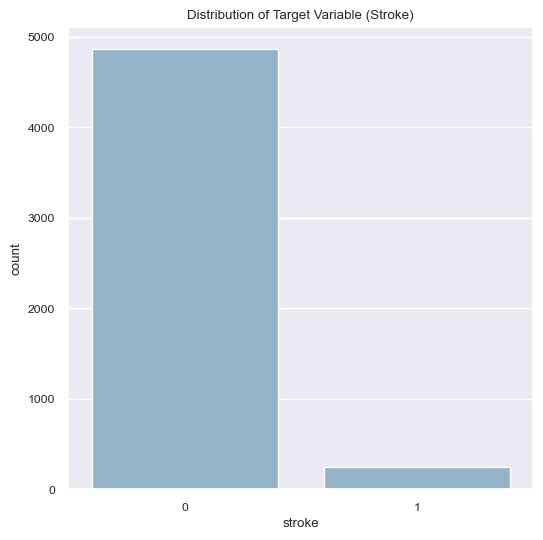

In [42]:
def target_variables(dataframe: pd.DataFrame) -> None:

    plt.figure(figsize=(6, 6))
    sns.countplot(x=dataframe['stroke'])
    plt.title("Distribution of Target Variable (Stroke)")
    plt.show()

target_variables(df)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>The interpretations of the results</b>
<br>The target variable 'stroke' is tremendously Uneven with frequent cases of class 0 (no stroke) than class 1 (stroke). This is a key observation as it will have an impact on the choice of machine learning model and evaluation metric. <br>
</div>

In [43]:
print(df.shape)
print(df.describe())
print(df.info())

(5110, 12)
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    33.1

In [44]:
print(df.isna().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Category Variables</h3>

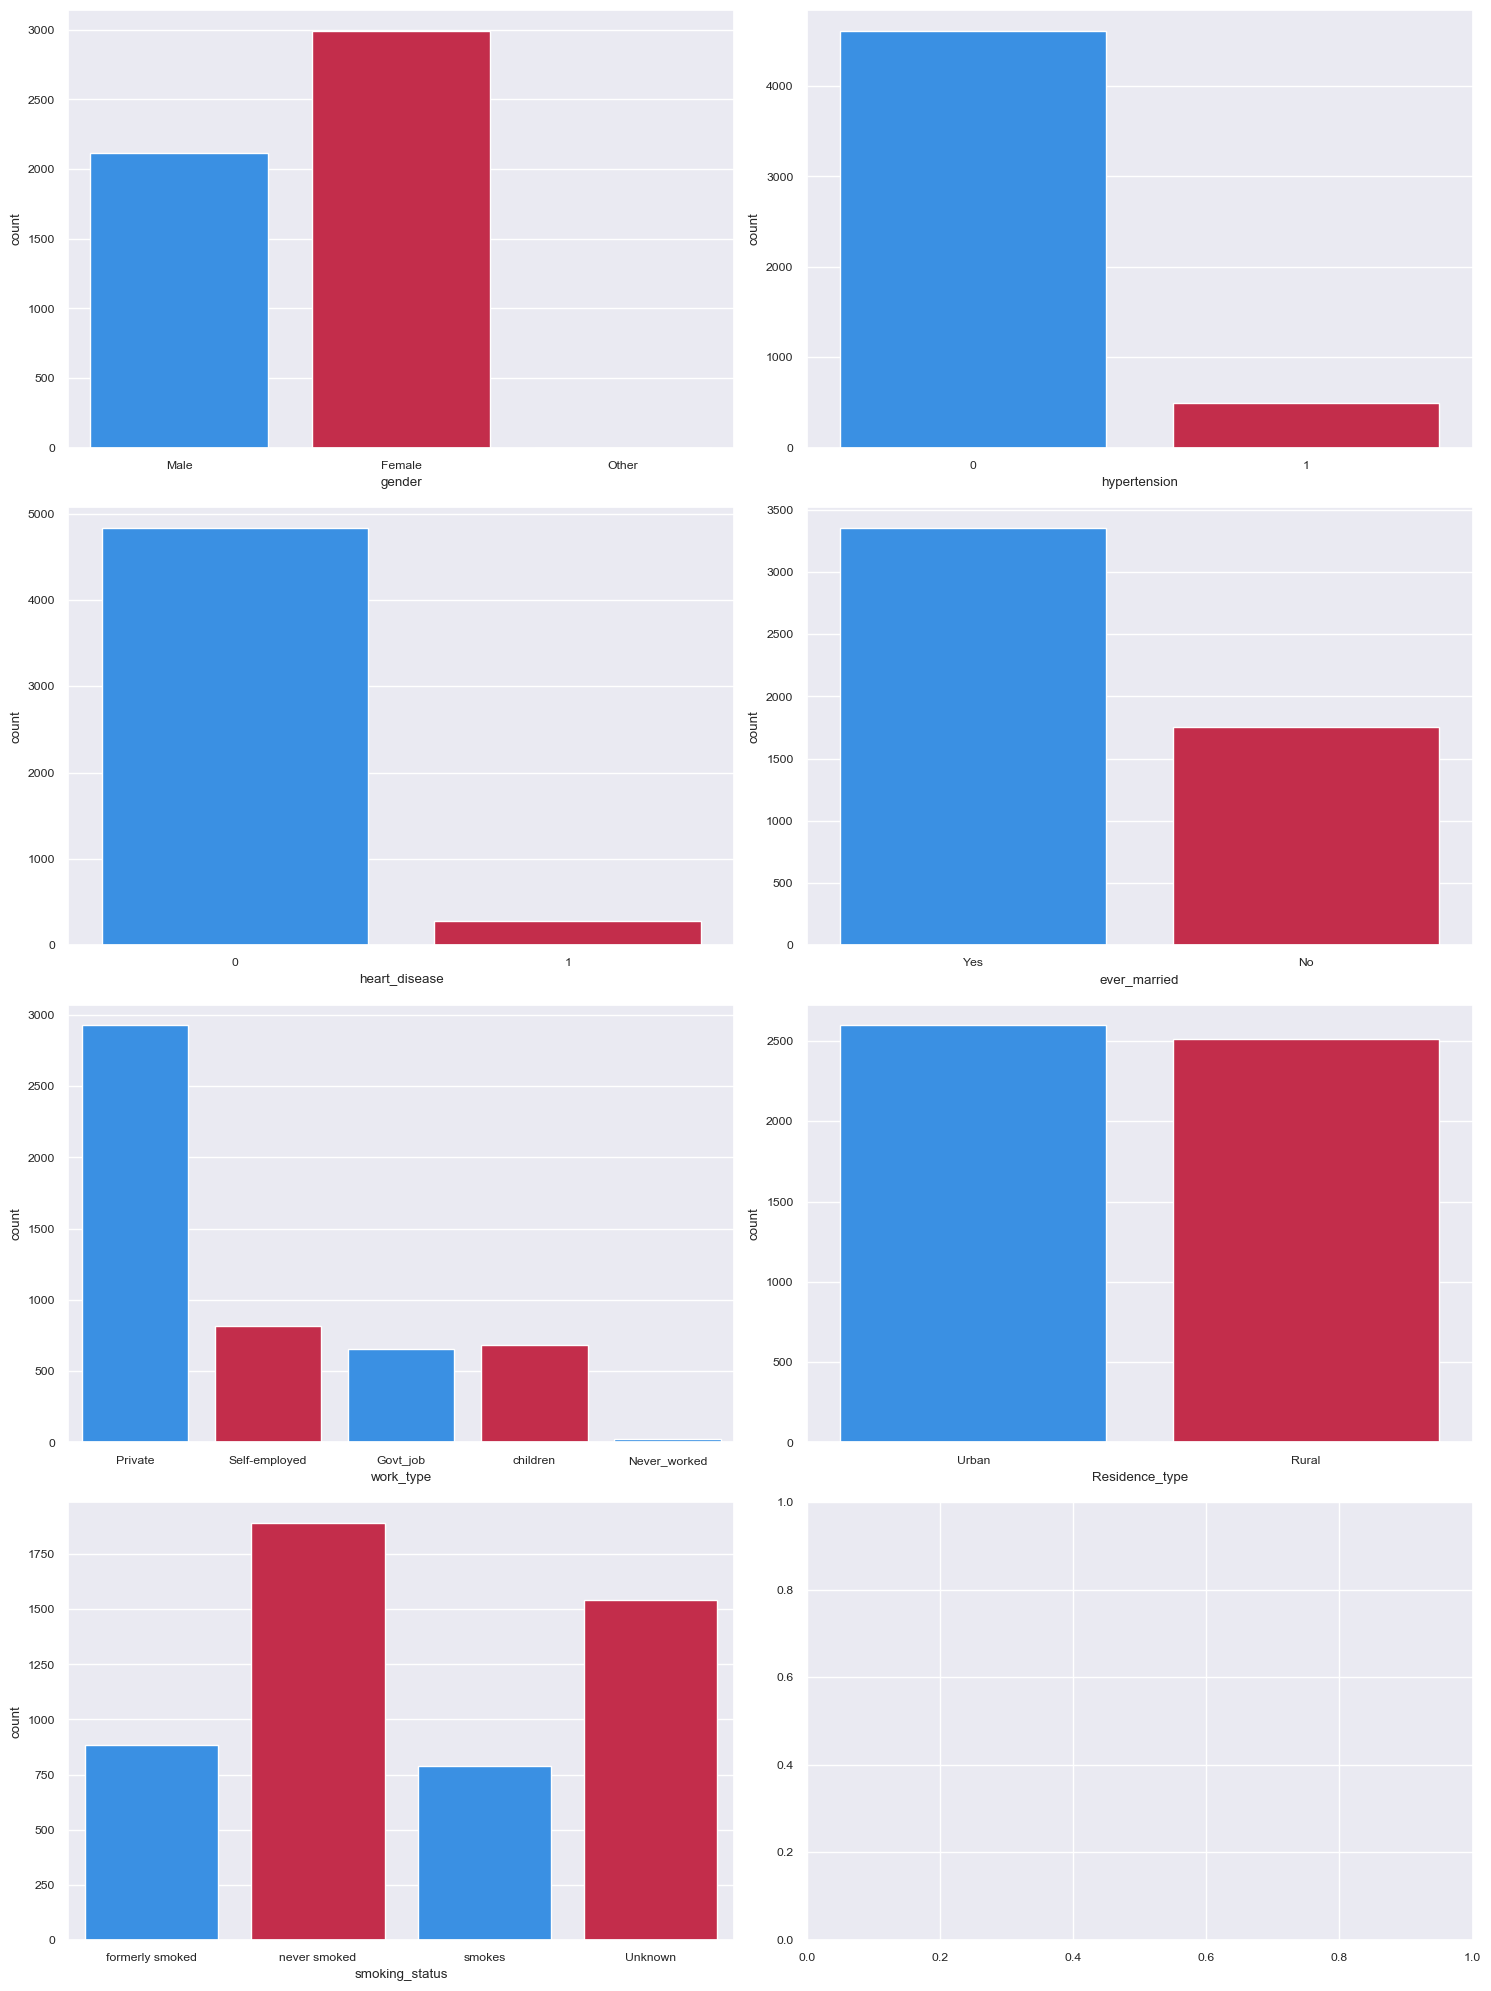

In [45]:
def category_vairables(dataframe: pd.DataFrame) -> None:

    binary_palette = ["dodgerblue", "crimson"]

    categorical_variables = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15,20))


    for var, subplot in zip(categorical_variables, axes.flatten()):
        sns.countplot(x=var, data=dataframe, ax=subplot, palette=binary_palette)
    '''    for label in subplot.get_xticklabels():
            label.set_rotation(45)'''

    plt.tight_layout()
    plt.show()

category_vairables(df)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>The interpretations of the results</b>
<br><br>

1. **gender**: There are more female than male patients, and the number of patients who identity themselves as others are quite minute
2. **hypertension**: The major part of the pationts do not have hypertension.
3. **heart_disease**: The majority of patients do not have heart disease.
4. **ever_married**: A high percentage of patients report ever-married status
5. **work_type**: The private working employees comprise the largest share of the patient base. Moreover, the self-employed individuals and children also take a considerable part. Meanwhile, public sector workers and those who have never worked account for the lowest percentages.

</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Continous Vairables</h3>

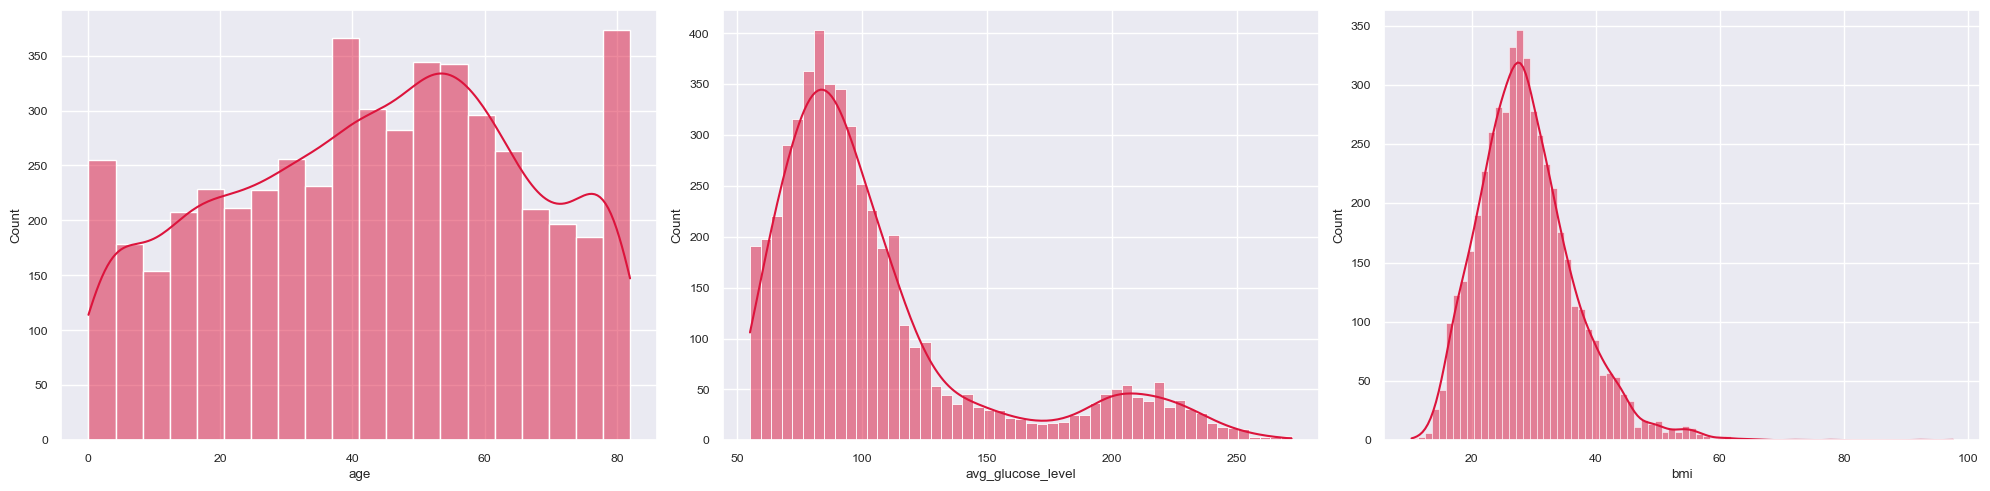

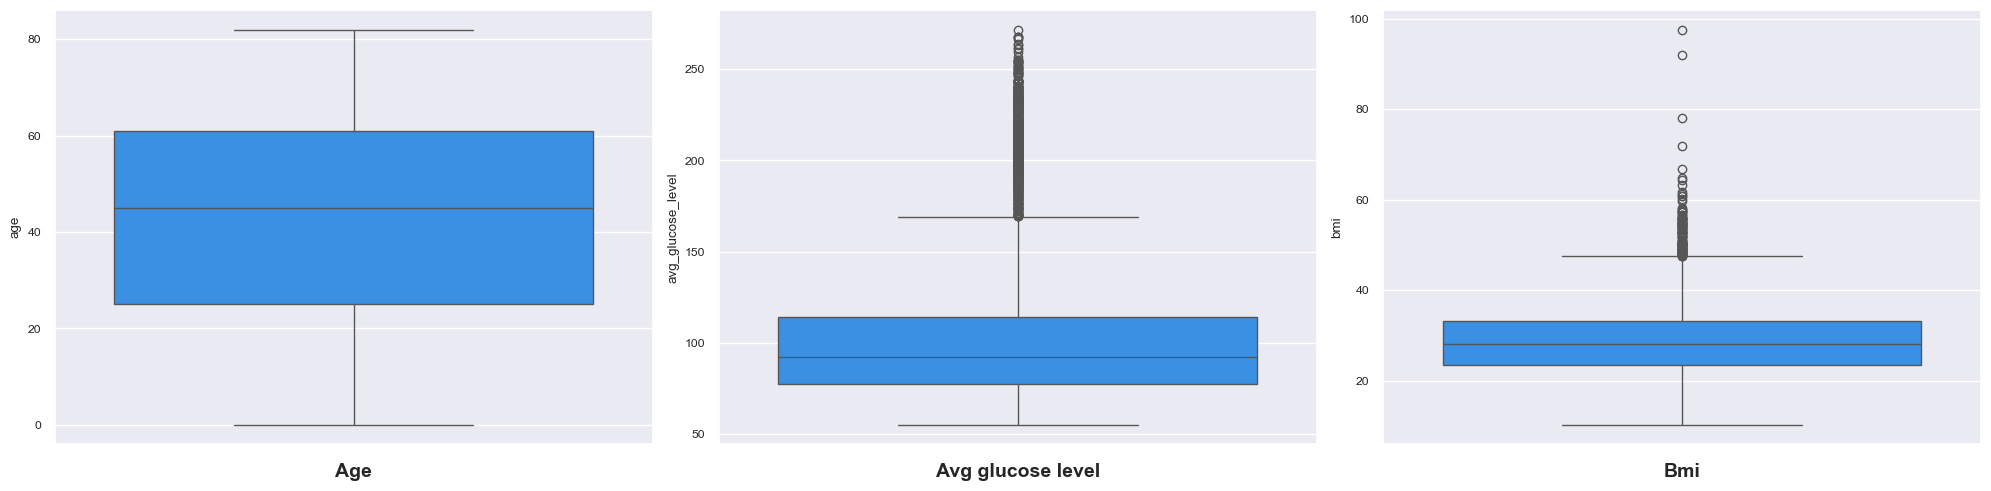

In [46]:
def continuous_variables_histogram(dataframe: pd.DataFrame) -> None:
    continuous_variables = ["age", "avg_glucose_level", "bmi"]
    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.histplot(dataframe[var], kde=True, ax=subplot, color='crimson')

    plt.tight_layout()
    plt.show()

def continuous_variables_boxplot(dataframe: pd.DataFrame) -> None:
    continuous_variables = ["age", "avg_glucose_level", "bmi"]
    fig, axs = plt.subplots(1, 3, figsize=(20,5))

    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.boxplot(y=dataframe[var], ax=subplot, color='dodgerblue')
        subplot.set_xlabel(var.replace("_", " "). capitalize(), fontsize=14, fontweight='bold')
        subplot.set_title("")

    plt.tight_layout()
    plt.show()

continuous_variables_histogram(df)
continuous_variables_boxplot(df)


<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Continous Variables analysis</b>
<br><br>

1. **age**: the average age of the patients is above 40, and the majority of the patients are between 40-80 years

2. **avg_glucose_level**: The major part of the patients have an average glucose level between 50-125. But as we can see on the boxplot, there are also many patients with much higer glucose level.
3. **bmi**: The majority of the patients have a bmi int the range of 20-40, which is considered normal to overweight, but there are some extremely high outliers as well.
</div>


<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Bivariate Analysis</h3>

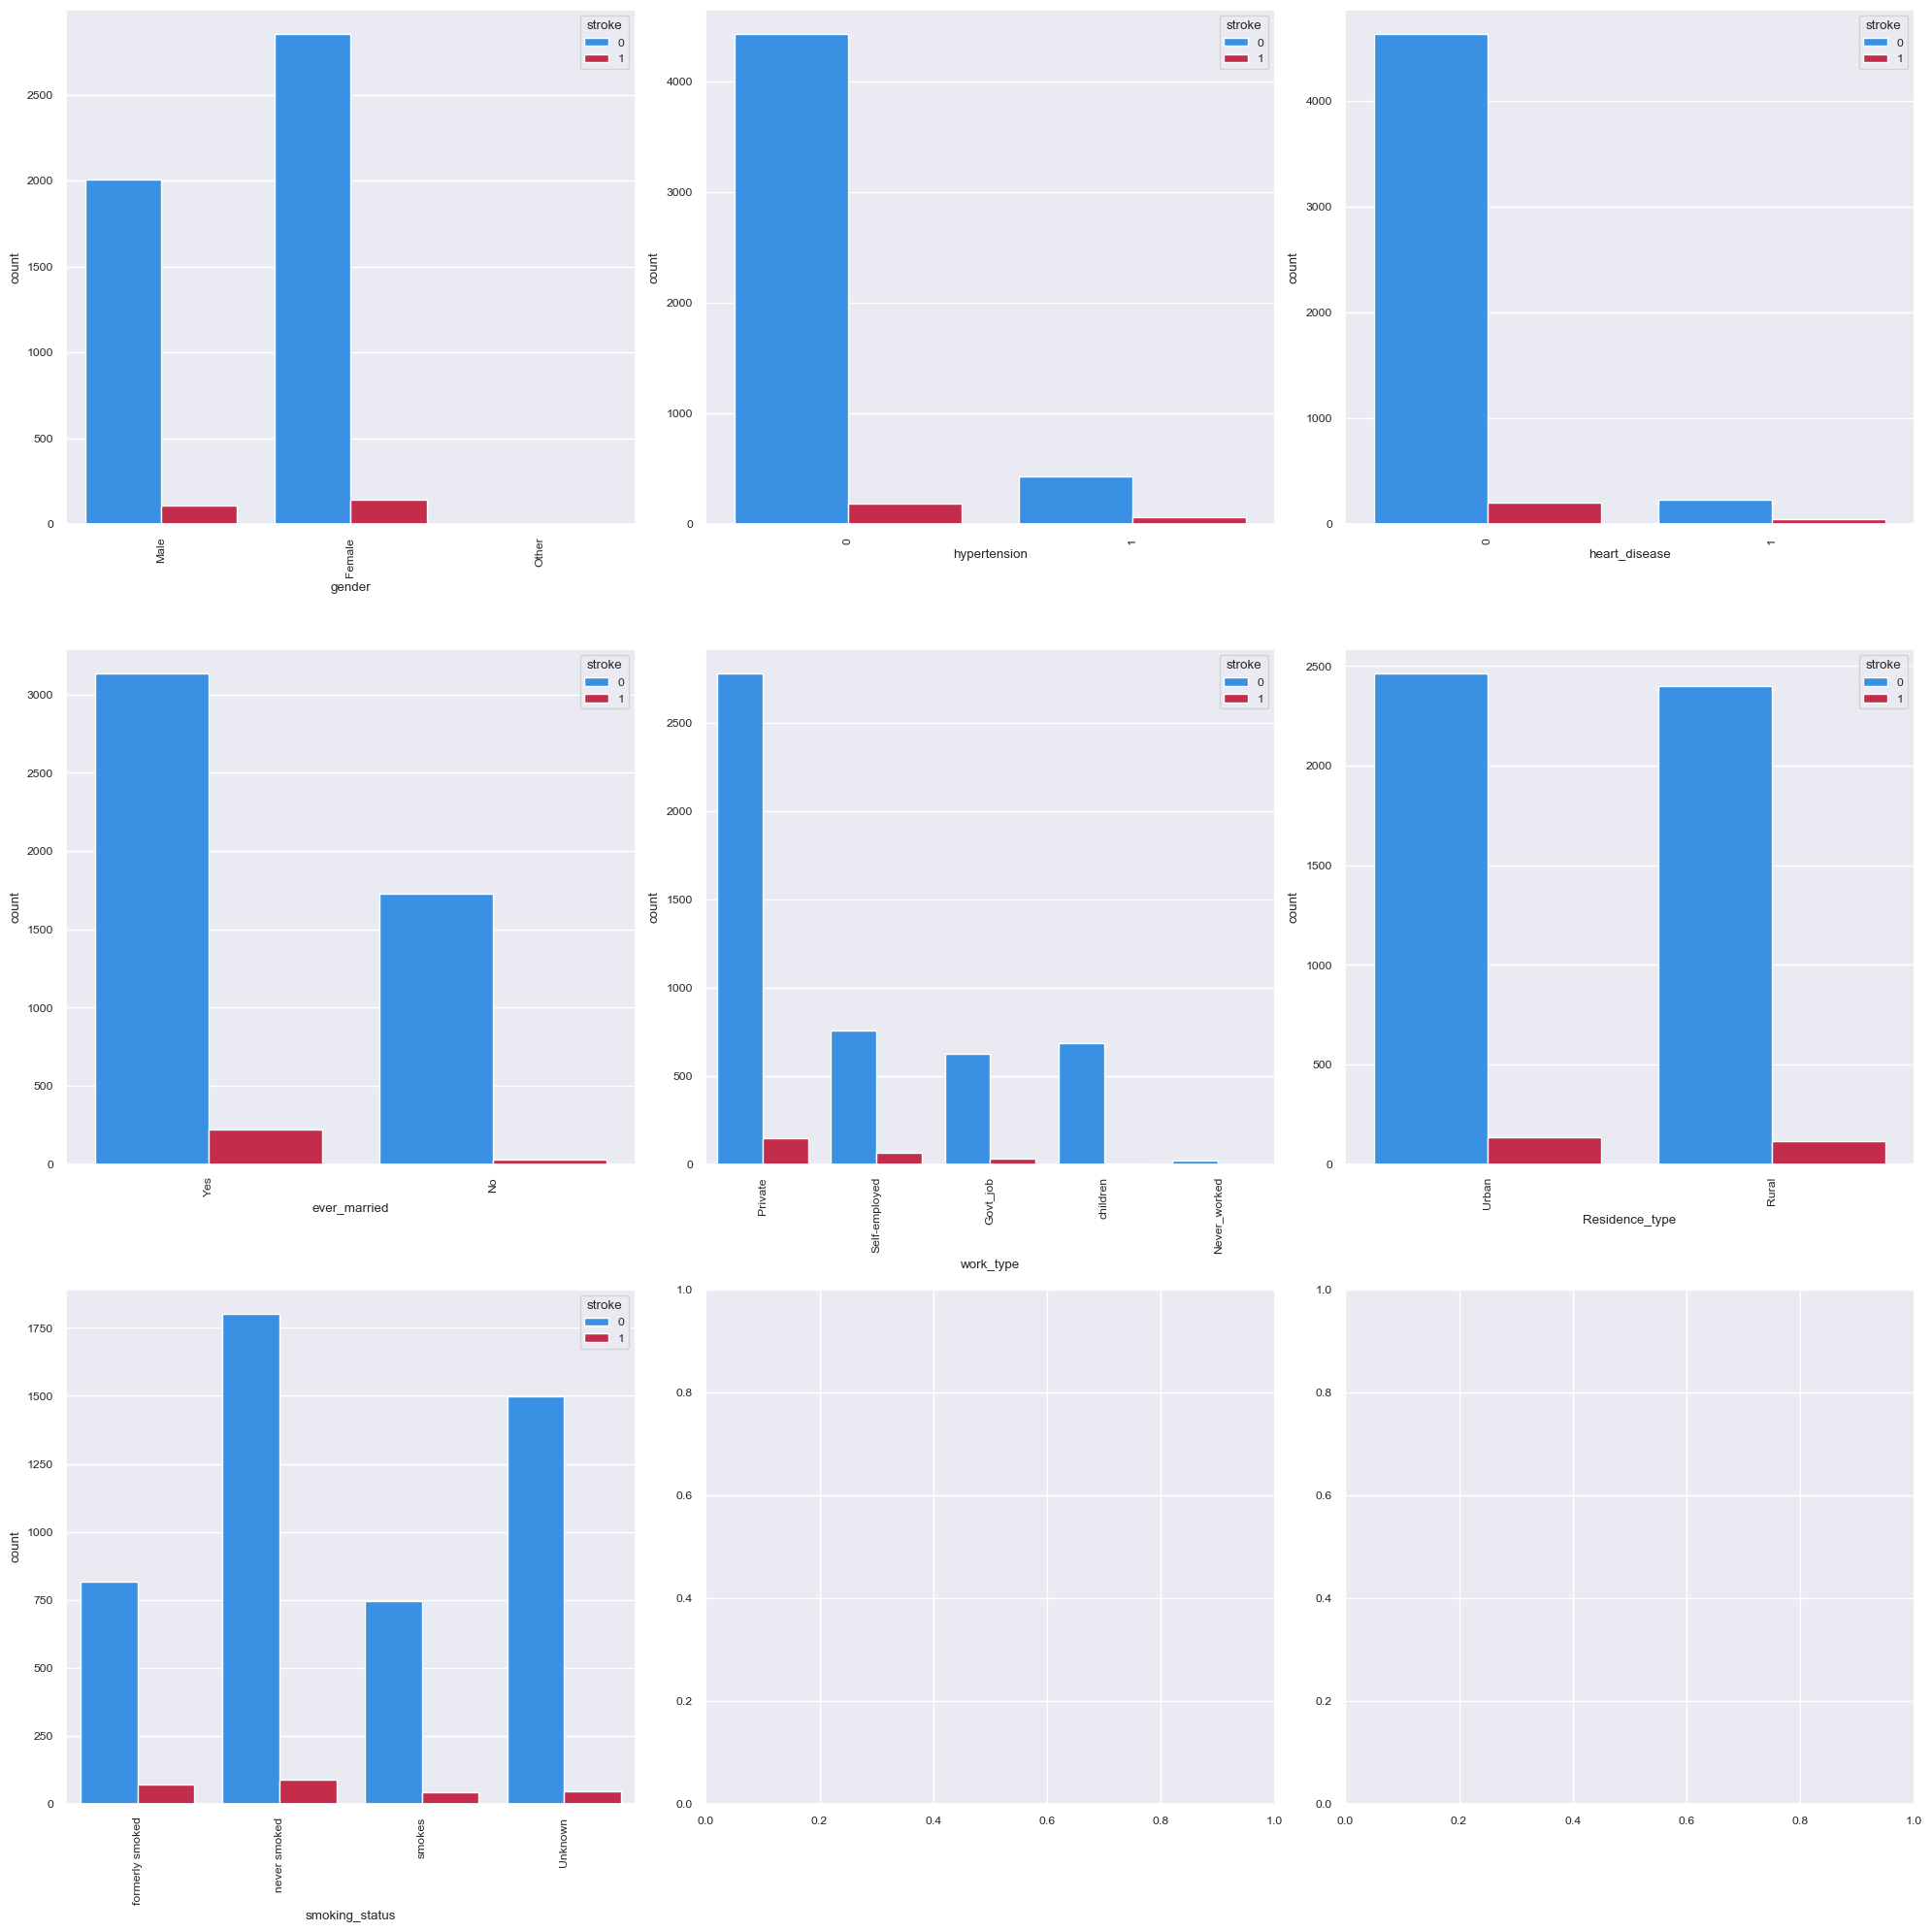

In [47]:
def bivariate_analysis_categorical(dataframe: pd.DataFrame) -> None:
    binary_palette = ["dodgerblue", "crimson"]
    categorical_variables = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

    # Javított sor: subplot -> subplots
    fig, axs = plt.subplots(3, 3, figsize=(20,20))

    for var, subplot in zip(categorical_variables, axs.flatten()):
        sns.countplot(x=dataframe[var], hue=dataframe["stroke"], ax=subplot, palette=binary_palette)
        for label in subplot.get_xticklabels():
            label.set_rotation(90)

    plt.tight_layout()
    plt.show()

bivariate_analysis_categorical(df)




<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Categorical Bivariate Analysis</b>
<br><br>

1. **gender**: Both males and females have a similar proportion of stoke cases, with a males having slightly more.

2. **hypertension**: Patients with hypertension have a higher proportion of stroke cases than those without hypertension.
3. **heart_disease**: Patients with head disease also have a higher proportion of stroke cases than those without heart disease.
4. **ever_married**: Those who have been married have a higher proportion of stroke cases than those who have not.
5. **work_type**: Patients who are self-employed or work in private jobs have a higher proportion of stroke cases compared to other work types
6. **Residence_type**: The proportion of stroke cases is almost equal for both urban and rural residents.
7. **smoking_status**: The proportion of stroke cases is higher for patients who formerly smoked or currently smoke compared to those who never smoked. The stroke proportion for the 'Unknown' category is lower.
</div>

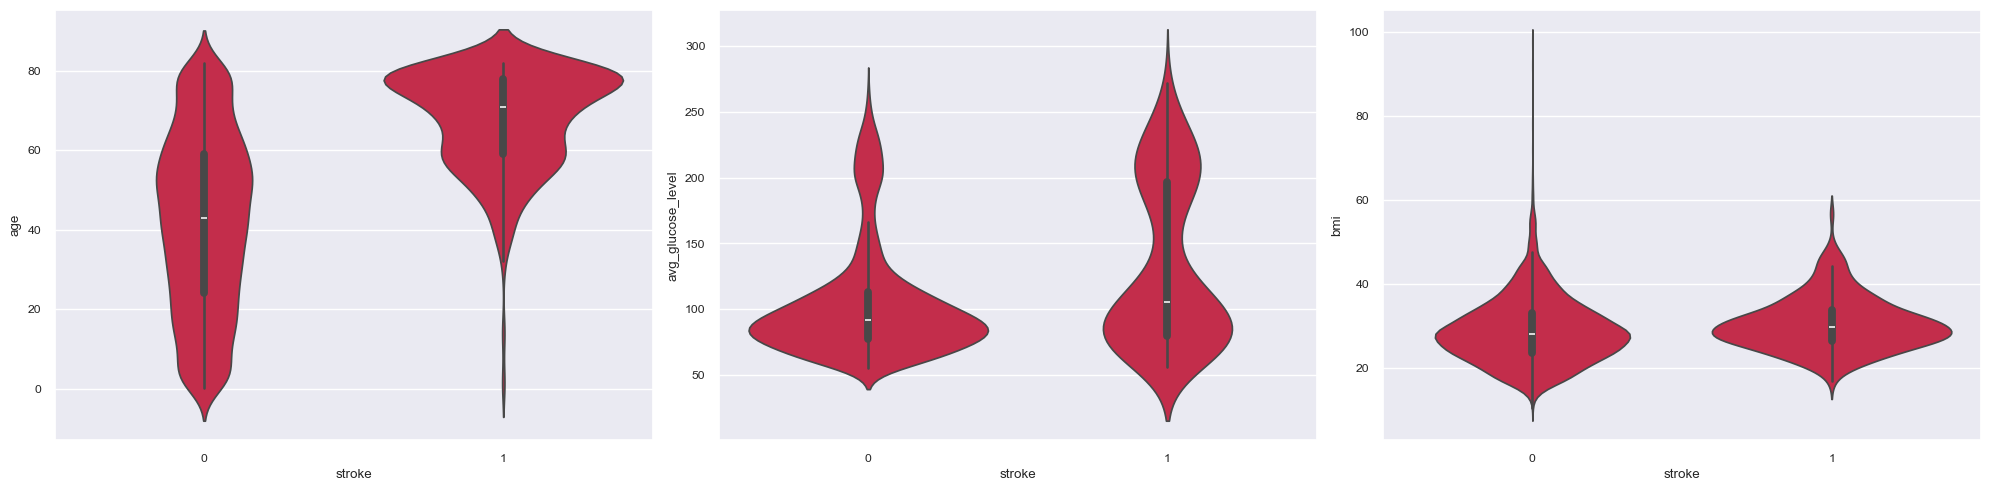

In [48]:
def bivariate_analysis_continuous(dataframe: pd.DataFrame) -> None:
    continuous_variables = ["age", "avg_glucose_level", "bmi"]
    fig, axs = plt.subplots(1,3,figsize=(20,5))
    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.violinplot(x=dataframe["stroke"], y=dataframe[var], ax=subplot, color="crimson")

    plt.tight_layout()
    plt.show()

bivariate_analysis_continuous(df)


<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Continuous Bivariate Analysis</b>
<br><br>

1. **Age**: Considering the older patients, in their cases it is more common having a stroke than the younger patients.

2. **Avg_glucose_level**: Those patients who had storke, they have a higher average glucose level than non stroke patients. There is a wider distribution of glucose levels among stroke patients.
3. **BMI**: the BMI distribution for stroke and non-stroke patients are quite similar, suggesting that BMI might not be a strong predictor for stroke.
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Multivariate Analysis</h3>


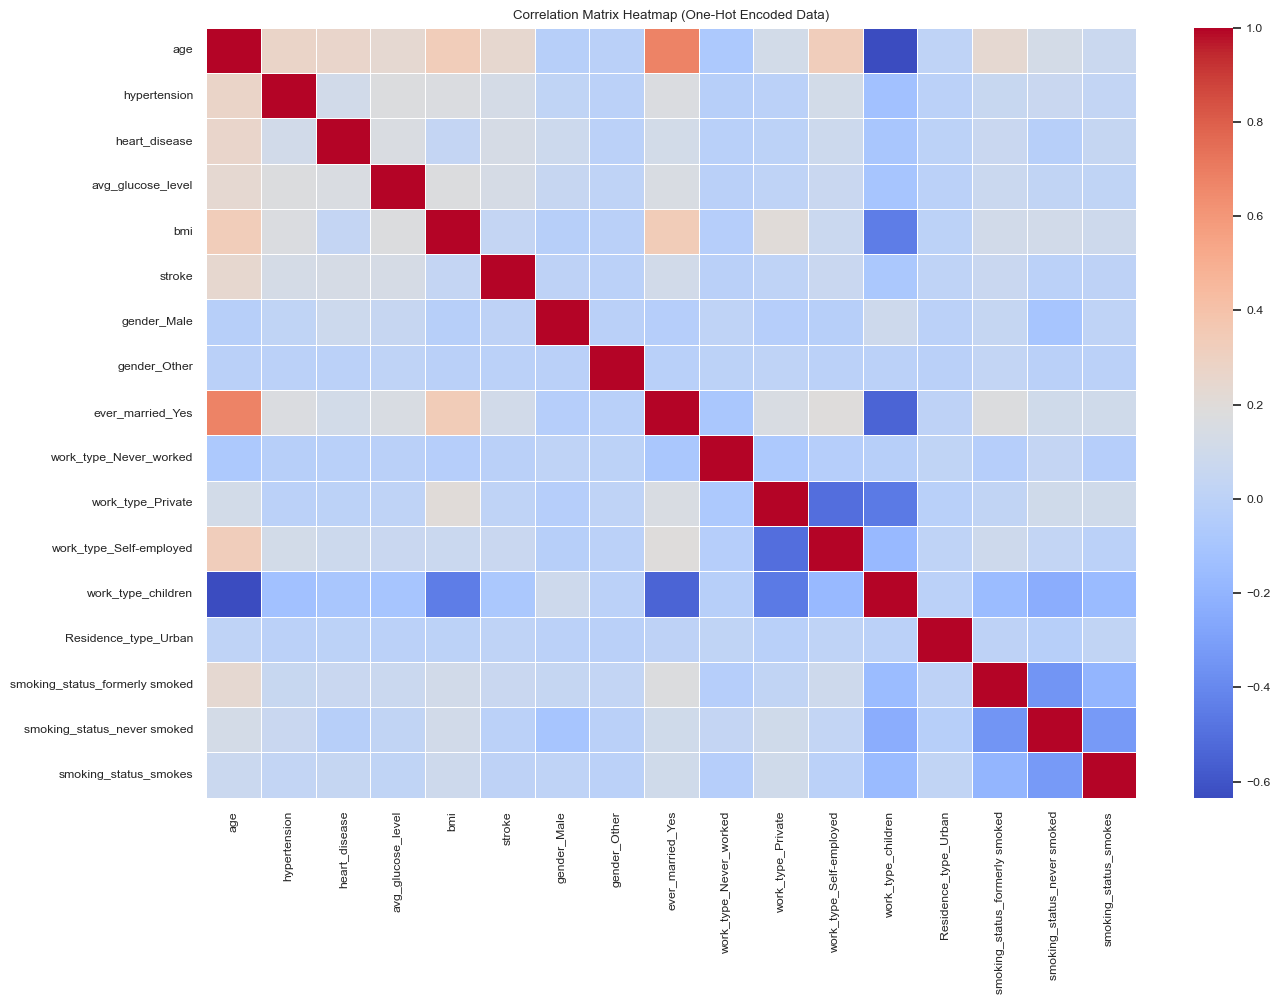

In [49]:
def correlation_matrix(filepath: str):
    data_original = load_the_data(filepath)

    # Javítás: inplace=True hozzáadása az id oszlop végleges törléséhez
    data_original.drop("id", axis=1, inplace=True)

    categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

    # Javítás: 'spare' helyett 'sparse_output' (újabb scikit-learn verziókhoz)
    one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False)

    encoded_array = one_hot_encoder.fit_transform(data_original[categorical_cols])
    one_hot_encoded_df = pd.DataFrame(encoded_array, columns=one_hot_encoder.get_feature_names_out(categorical_cols))

    data_original.drop(categorical_cols, axis=1, inplace=True)
    data_one_hot_encoded = pd.concat([data_original, one_hot_encoded_df], axis=1)

    correlation_matrix_one_hot = data_one_hot_encoded.corr()
    return correlation_matrix_one_hot

def overall_correlation(filepath: str):
    correlation_matrix_one_hot = correlation_matrix(filepath)
    plt.figure(figsize=(15, 10))
    sns.heatmap(correlation_matrix_one_hot, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title("Correlation Matrix Heatmap (One-Hot Encoded Data)")
    plt.show()

overall_correlation("healthcare-dataset-stroke-data.xls")

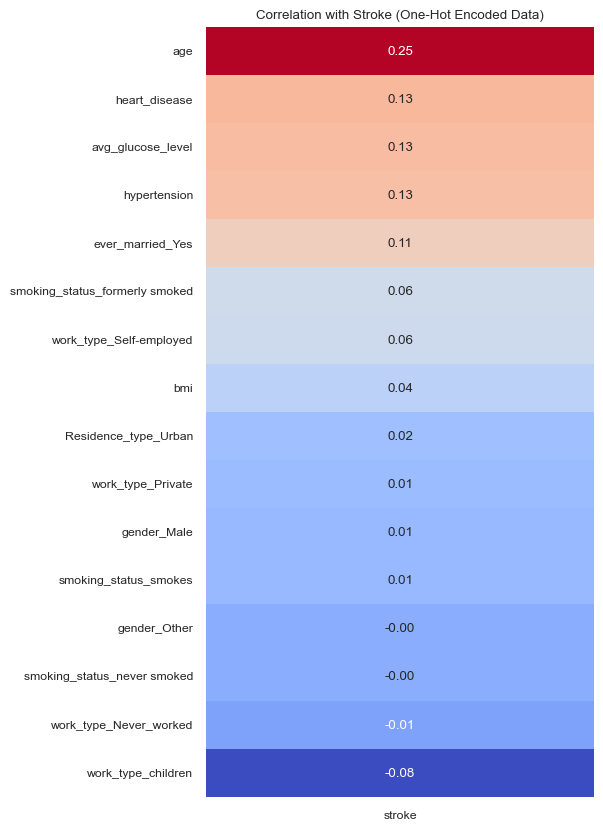

In [50]:
def target_correlation(filepath: str) -> None:
    correlation_matrix_one_hot  = correlation_matrix(filepath)
    target_corr_one_hot  = correlation_matrix_one_hot["stroke"].drop("stroke")
    target_corr_sorted_one_hot = target_corr_one_hot.sort_values(ascending=False)

    plt.figure(figsize=(5,10))
    sns.set(font_scale=0.8)
    sns.set_style("white")
    sns.set_palette("PuBuGn_d")
    sns.heatmap(target_corr_sorted_one_hot.to_frame(), cmap="coolwarm", annot=True, fmt=".2f", cbar=False)
    plt.title("Correlation with Stroke (One-Hot Encoded Data)")
    plt.show()

target_correlation("healthcare-dataset-stroke-data.xls")


<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Overall Correlation Heatmap</b>
<br><br>

The first heatmap provides a visualization of the correlation between all pairs of features in the dataset. The color of each cell represents the correlation coefficient between the pair of variables: **Blue** for positive correlation and **red** for negative correlation. The darker the color, the stronger the correlation.

**Correlation with the Target Variable 'Stroke'**: The second heatmap ranks the features based on their correlation with the target variable _stroke_.

From the second heatmap, we can make several observations:

1. The _**age**_ variable demonstrates the highest positive correlation with the _**stroke**_ target variable. This indicates that older individuals are exposed to a higher risk of stroke, which aligns with clinically established facts.

2. The _**hypertension**_ and _**heart_disease**_ features similarly exhibit a positive correlation with _**stroke**_. This implies that individuals suffering from high blood pressure or heart conditions have an increased probability of experiencing a stroke.

3. The parameters _**avg_glucose_level**_ and _**ever_married_Yes**_ also indicate a positive relationship, suggesting that elevated average blood glucose levels, as well as being married, may be associated with a higher predisposition to strokes.

4. The positive correlation of the _**work_type_Self-employed**_ and _**gender_Male**_ variables highlights that self-employed individuals and males may have a slightly elevated likelihood of suffering a stroke.

5. In contrast, factors such as _**work_type_children**_ and _**Residence_type_Urban**_ display a negative correlation with _stroke_. From this, it can be deduced that these parameters are linked to a lower risk of stroke occurrence.

</div>

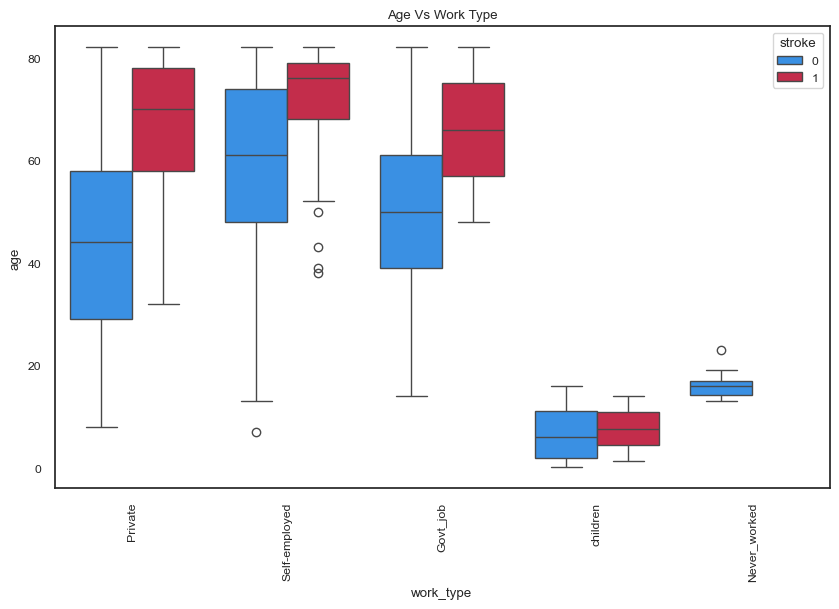

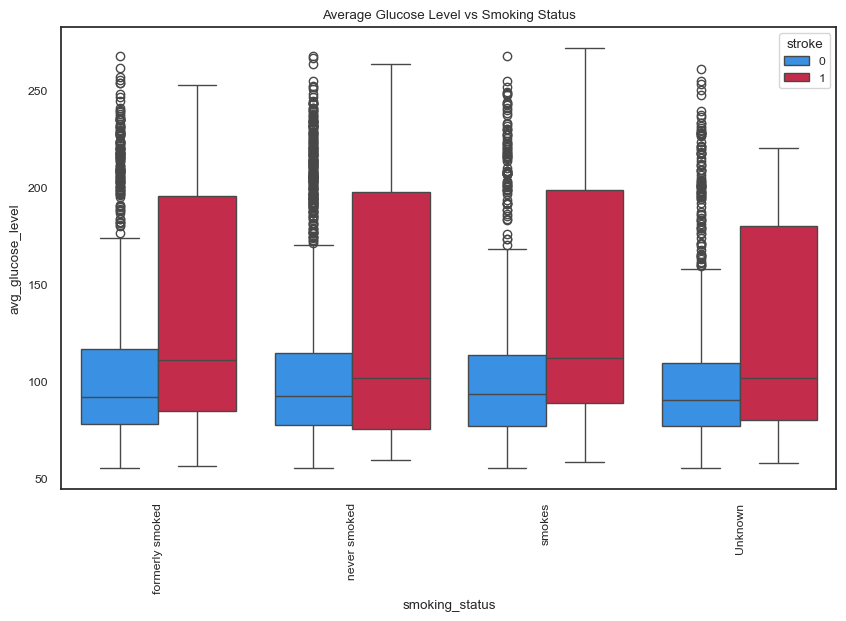

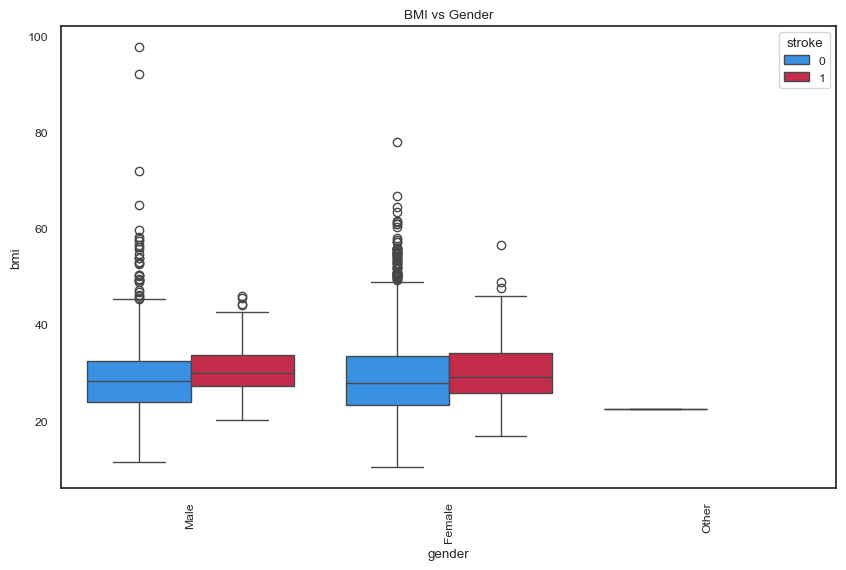

In [51]:
def age_worktype_boxplot(dataframe: pd.DataFrame) -> None:
    binary_palette = ["dodgerblue", "crimson"]
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=dataframe['work_type'], y=dataframe['age'], hue=dataframe['stroke'],palette=binary_palette)
    plt.title("Age Vs Work Type")
    plt.xticks(rotation=90)
    plt.show()


def avg_glucose_level_vs_smoking_boxplot(dataframe: pd.DataFrame) -> None:
    binary_palette = ["dodgerblue", "crimson"]
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=dataframe['smoking_status'], y=dataframe['avg_glucose_level'], hue=dataframe['stroke'], palette=binary_palette)
    plt.title("Average Glucose Level vs Smoking Status")
    plt.xticks(rotation=90)
    plt.show()


def bmi_vs_gender_boxplot(dataframe: pd.DataFrame) -> None:
    binary_palette = ["dodgerblue", "crimson"]
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=dataframe['gender'], y=dataframe['bmi'], hue=dataframe['stroke'], palette=binary_palette)
    plt.title("BMI vs Gender")
    plt.xticks(rotation=90)
    plt.show()


age_worktype_boxplot(df)
avg_glucose_level_vs_smoking_boxplot(df)
bmi_vs_gender_boxplot(df)



<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Overall Correlation Heatmap</b>
<br><br>

1. **Age vs. Work Type:** The incidence of stroke is notably higher among older individuals, specifically those engaged in self-employment or private sector roles. The highest median age for stroke patients is observed within the self-employed demographic. Conversely, the occurrence of strokes among children is exceptionally rare.

2. **Average Glucose Level vs. Smoking Status:** The median glucose level among stroke patients is elevated across all smoking status categories. Furthermore, individuals classified as former or current smokers exhibit a broader distribution of glucose levels, indicating greater physiological variability within these subgroups.

3. **BMI vs. Gender:** The distribution of Body Mass Index (BMI) is largely comparable between males and females. The incidence of stroke does not exhibit a significant correlation with BMI variations within either gender category. Notably, however, there are isolated cases of females with exceptionally high BMI values who have suffered a stroke.

</div>

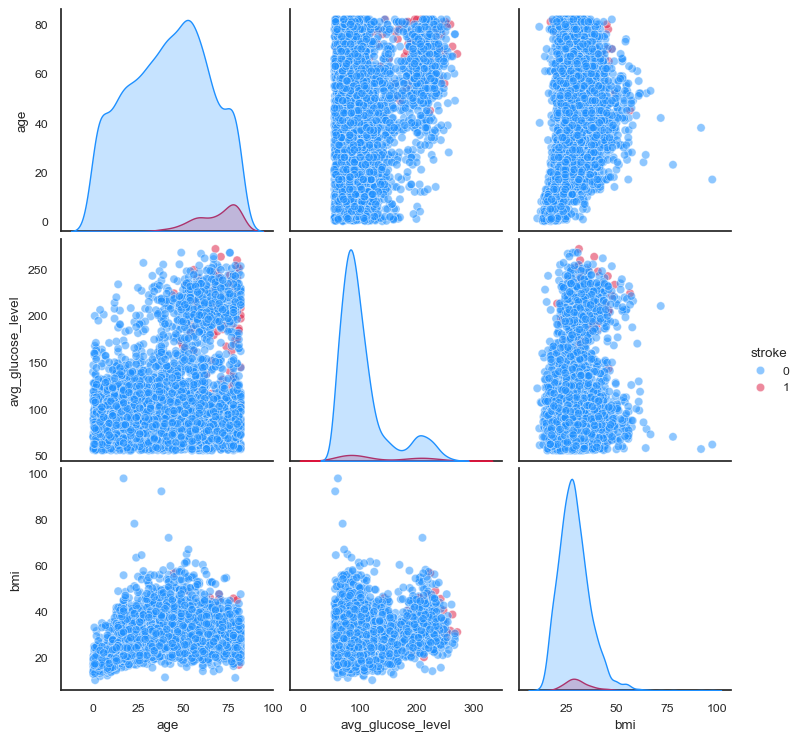

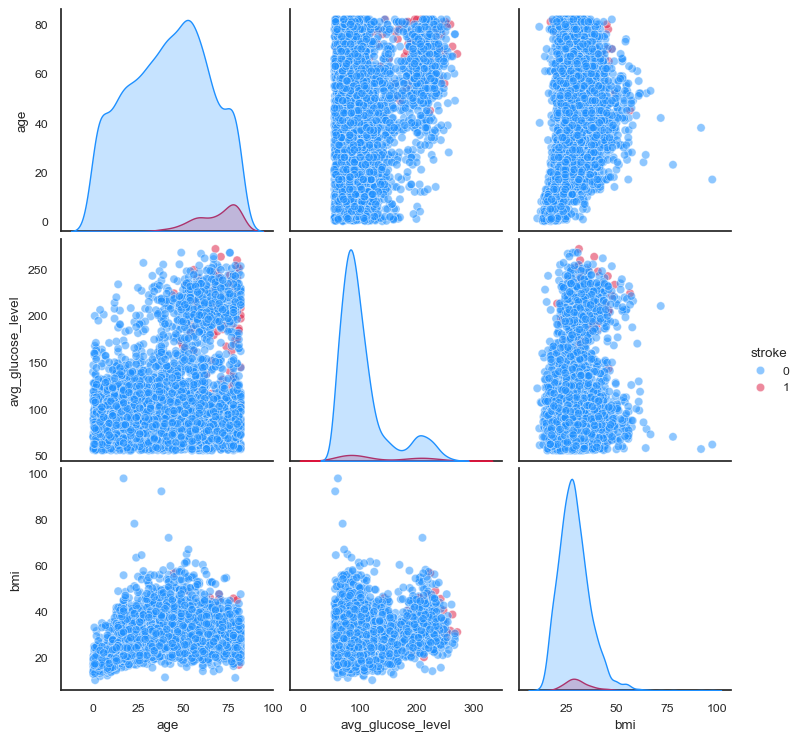

In [52]:
def pairplot_without_stroke(dataframe: pd.DataFrame) -> None:
    binary_palette = ["dodgerblue", "crimson"]
    subset = dataframe[["age", "avg_glucose_level", 'bmi', 'stroke']]
    subset["stroke"] = subset["stroke"].astype('category')
    sns.pairplot(subset, hue="stroke", plot_kws={"alpha": 0.5}, palette=binary_palette)
    plt.show(0)


pairplot_without_stroke(df)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Pairplot</b>
<br><br>
The pairplot gives us a visual overview of the pairwise relationships and distributions of age, avg_glucose_level, and bmi, separated by stroke status. Here are some observations:

1. **Age vs. Average Glucose Level:** There is no distinct correlation between age and average blood glucose levels. However, individuals who have experienced a stroke (indicated in orange) generally fall into a higher age bracket and exhibit elevated glucose levels.

2. **Age vs. BMI:** No significant relationship is evident between age and Body Mass Index (BMI). While stroke patients are predominantly older, their BMI values do not demonstrate a meaningful deviation from those of the non-stroke population.

3. **Average Glucose Level vs. BMI:** There is no observable correlation between average glucose levels and BMI. Nonetheless, stroke patients consistently present higher glucose levels, independent of their BMI measurements.
4. **Diagonal Distributions:** The diagonal plots illustrate the individual distributions of each variable for both stroke and non-stroke cohorts. These validate the preliminary findings from the univariate analysis: stroke incidence is primarily associated with advanced age and elevated glucose levels, whereas the BMI distribution remains largely consistent across both groups.

</div>

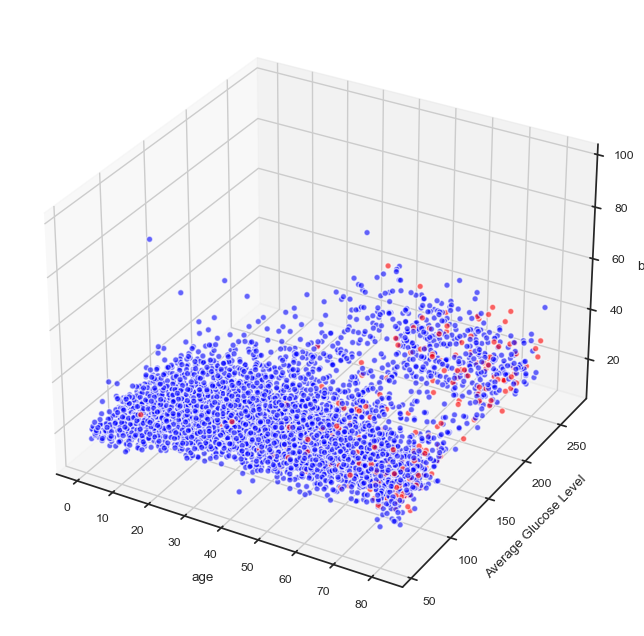

In [53]:
def scatter_three_d(dataframe: pd.DataFrame) -> None:
    colors = dataframe["stroke"].map({0:"blue", 1:"red"})
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(dataframe["age"], dataframe['avg_glucose_level'], dataframe['bmi'], c=colors, alpha=0.6, edgecolors="w")

    ax.set_xlabel("age")
    ax.set_ylabel("Average Glucose Level")
    ax.set_zlabel("bmi")
    plt.show()


scatter_three_d(df)


<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>3D scatter plot</b>
<br><br>

The 3D scatter plot provides a three-dimensional representation of the interactions among _**age**_, _**avg_glucose_level**_, and _**bmi**_ in relation to _stroke_ status. Data points are color-coded to distinguish between patients who have experienced a stroke (red) and those who have not (blue).

Based on this visualization, the following key observations can be made:
1. **Age and Glucose Levels:** Stroke patients (indicated by the red points) predominantly skew towards an older demographic and exhibit elevated glucose levels. This corroborates the findings from previous stages of the analysis.

2. **BMI Overlap:** Body Mass Index (BMI) does not serve as a distinct differentiator between the two groups. There is a substantial overlap in the BMI values of stroke and non-stroke patients, reinforcing that BMI alone is not a primary indicator in this context.
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Results</h3>

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">

1. **Class Imbalance:** The target variable (_stroke_) demonstrates a severe structural imbalance, being predominantly skewed towards the negative class (no stroke). This disparity necessitates deliberate consideration when selecting predictive algorithms and establishing performance evaluation metrics.

2. **Categorical Predictors:** Variables including _gender_, _hypertension_, _heart_disease_, _ever_married_, _work_type_, _Residence_type_, and _smoking_status_ exhibit varied distributions. Notably, clinical diagnoses of hypertension or heart disease are registered at a significantly higher frequency among patients who have experienced a stroke.

3. **Continuous Predictors:** The numerical features (_age_, _avg_glucose_level_, and _bmi_) display distinct correlational trends. Advanced age and elevated average blood glucose levels demonstrate a strong positive association with stroke incidence. In contrast, BMI distributions remain largely uniform across both patient cohorts.
4. **Multivariate Patterns:** Advanced visual diagnostics, utilizing FacetGrids and parallel coordinates, reveal that older demographics, specifically those engaged in the private sector or self-employment are exposed to a heightened stroke risk. Furthermore, elevated glucose levels consistently emerge as a defining characteristic of stroke patients, independent of their gender or occupational classification.
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Discussion and Limitations</h3>

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">

1. **Implications for Modeling:** The exploratory analysis identifies crucial risk factors, which is mainly consists of  age, hypertension, cardiovascular conditions, and glucose levels—while indicating that BMI offers limited predictive utility. These findings will directly guide the feature engineering and selection phases. However, the pronounced class imbalance mandates the implementation of mitigation techniques, such as SMOTE, majority class undersampling, or hybrid resampling methods, to prevent algorithmic bias.

2. **Causality vs. Correlation:** Although the observed distributional patterns provide substantial statistical signals, these correlations do not inherently prove causation. Establishing definitive causal pathways would require rigorous statistical validation or controlled clinical frameworks.

3. **Unmeasured Covariates:** The scope of this analysis is fundamentally constrained by the available dataset. Critical external determinants, such as: family medical history, lifestyle factors (dietary habits, physical activity, alcohol consumption), and chronic stress levels are absent. The integration of these variables in future iterations would significantly enhance the robustness and accuracy of the predictive framework.

</div>

<h2 style="background-color: #99022f; color: white; padding: 15px; border-radius: 5px; margin-top: 0;"> Data Cleaning </h2>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;"> Missing Values </h3>

In [54]:
data = load_the_data('healthcare-dataset-stroke-data.xls')

data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">

As you can see on the table, the BMI column has 201 missing values. In order to make our prediction as accurate as possbible, we have to handle the missing values. We have a few options to solve this problem:

1. **Remove the rows with missing values:** This is a good option if the number of missing values is relatively small, and we don't risk losing too much data. However, this method can introduce bias if the missing data is not random.

2. **Impute missing values:** This involves filling in the missing values based on other data. Common methods include using the mean, median, or mode of the column, or using a more complex method like regression or machine learning algorithms to predict the missing values.

3. **Leave them as is:** In certain cases (e.g., certain machine learning algorithms can handle missing values), we might leave the missing values

In our case, since BMI is a significant variable and we have a relatively large number of missing values, it would be reasonable to impute these missing values.

</div>

In [55]:
from sklearn.neighbors import KNeighborsRegressor

def knn_impute(df: pd.DataFrame, na_target: str) -> pd.DataFrame:

    df = df.copy()

    numeric_df = df.select_dtypes(include=[np.number])

    non_na_columns = numeric_df.loc[: ,numeric_df.isna().sum() == 0].columns

    y_train = numeric_df.loc[numeric_df[na_target].isna() == False, na_target]
    X_train = numeric_df.loc[numeric_df[na_target].isna() == False, non_na_columns]
    X_test = numeric_df.loc[numeric_df[na_target].isna() == True, non_na_columns]

    knn = KNeighborsRegressor()
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    df.loc[df[na_target].isna() == True, na_target] = y_pred

    return df

na_cols = [col for col in data.columns if data[col].isnull().sum()!=0]

for col in na_cols:
    data = knn_impute(data, col)

In [56]:
data.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
We have successfully filled in the missing bmi values with the median of the existing values. Now there are no missing values in our dataset.
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;"> Duplicates </h3>

In [57]:
def duplicates(df: pd.DataFrame) -> int:
    return df.drop("id", axis=1).duplicated().sum()

duplicates(data)

np.int64(0)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
There are no duplicate rows in our dataset, which is good news</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;"> Outliers </h3>

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
Next, let's check for outliers in our numerical columns
</div>

In [58]:
def count_outliers(column: str):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return ((column < lower_bound) | (column > upper_bound)).sum()

outliers = {column: count_outliers(data[column]) for column in ["age", 'avg_glucose_level', 'bmi']}

outliers

{'age': np.int64(0), 'avg_glucose_level': np.int64(627), 'bmi': np.int64(117)}

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
The avg_glucose_level column has 380 outliers and the bmi column has 73 outliers, while age doesn't have any
</div>

In [59]:
zero_or_negative_values = {column: (data[column] <= 0).sum() for column in ['avg_glucose_level', 'bmi']}

zero_or_negative_values

{'avg_glucose_level': np.int64(0), 'bmi': np.int64(0)}

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
There are no zero or negative values in the avg_glucose_level and bmi columns, so we can safely apply the log transformation.
</div>

{'avg_glucose_level': np.int64(380), 'bmi': np.int64(73)}


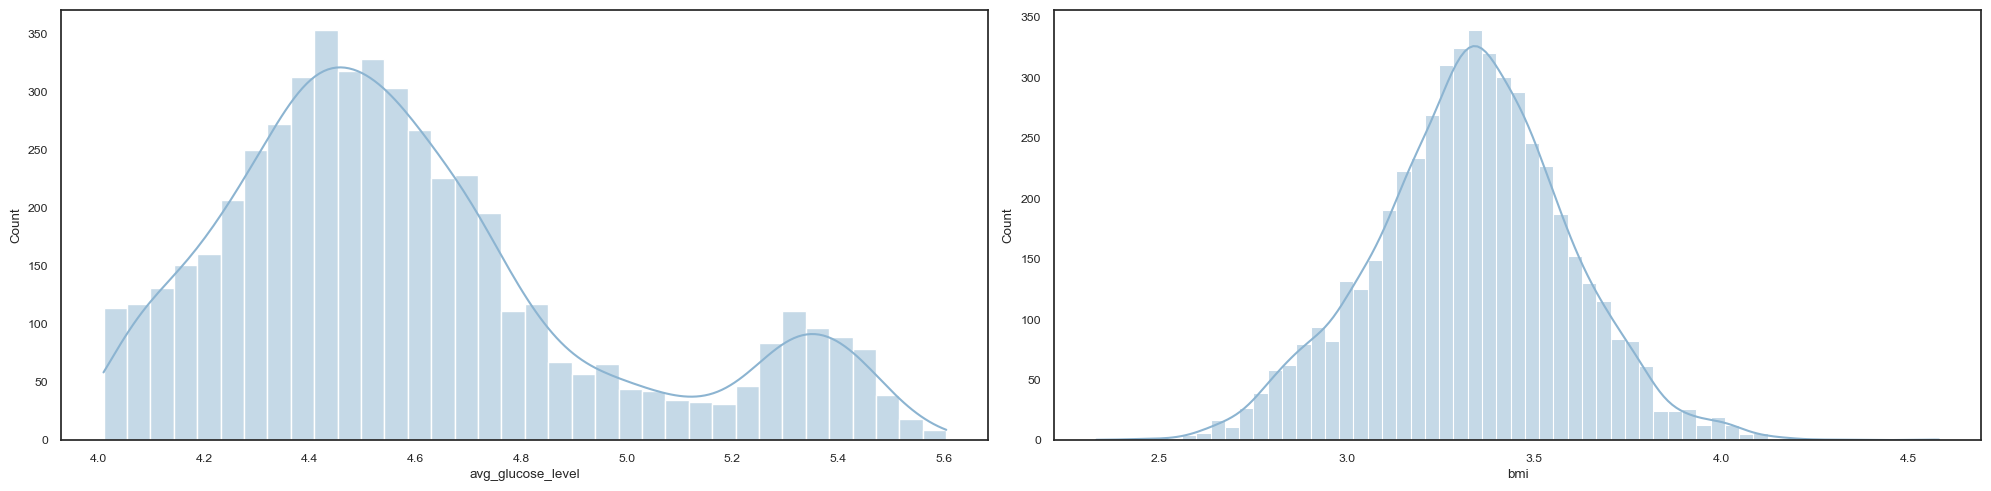

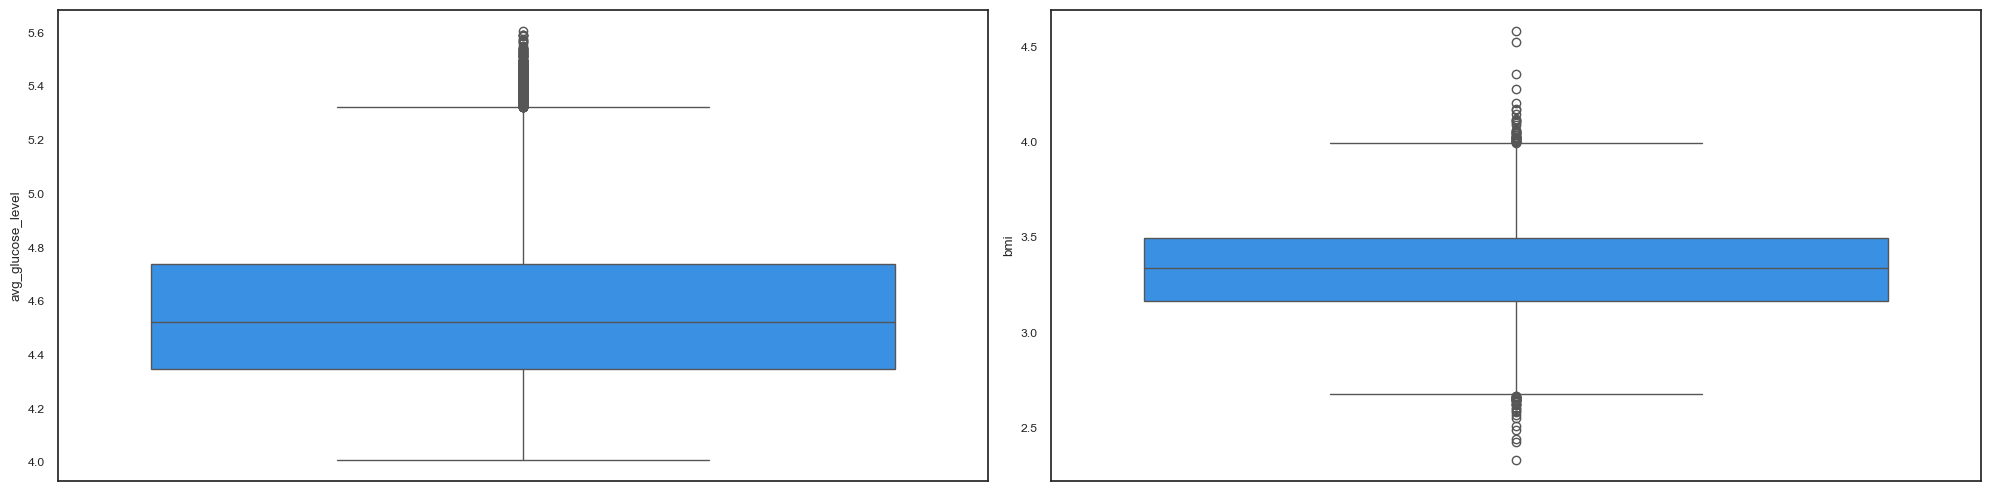

In [60]:
def log_transformation(df: pd.DataFrame) -> None:

    binary_palette = ["dodgerblue", ]
    df['avg_glucose_level'] = np.log(data['avg_glucose_level'])
    df['bmi'] = np.log(data['bmi'])

    outliers_transformed = {column: count_outliers(df[column]) for column in ['avg_glucose_level', 'bmi']}

    print(outliers_transformed)

    continuous_variables = ['avg_glucose_level', 'bmi']

    fig, axs = plt.subplots(1, 2, figsize=(20, 5))

    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.histplot(df[var], kde=True, ax=subplot, palette=binary_palette)

    plt.tight_layout()
    plt.show()

    fig, axs = plt.subplots(1, 2, figsize=(20, 5))

    for var, subplot in zip(continuous_variables, axs.flatten()):
        sns.boxplot(df[var], ax=subplot, palette=binary_palette)

    plt.tight_layout()
    plt.show()

log_transformation(data)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
The log transformation has reduced the number of outliers in the avg_glucose_level and bmi columns.
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;"> Encoding </h3>

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">

Machine learning algorithms require numerical input, so we will encode our categorical features. We will implement one-hot encoding to map each category to a new binary column. First, let us examine the unique values within these columns.

</div>

In [61]:
unique_values_categorical = {column: data[column].unique() for column in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']}

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">

The unique values in the categorical columns are as follows:
1. **gender**: ['Male', 'Female', 'Other']
2. **ever_married**: ['Yes', 'No']
3. **work_type**: ['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
4. **Residence_type**: ['Urban', 'Rural']
5. **smoking_status**: ['formerly smoked', 'never smoked', 'smokes', 'Unknown']


</div>

In [62]:
other_gender_count = (data['gender'] == 'Other').sum()
unknown_smoking_status_count = (data['smoking_status'] == 'Unknown').sum()

other_gender_count, unknown_smoking_status_count

(np.int64(1), np.int64(1544))

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">

The dataset contains a single observation designated as 'Other' for gender, alongside 1,544 records with an 'Unknown' smoking status. Given the statistical insignificance of a single data point, removing the 'Other' gender record is justified. Its exclusion will not compromise the integrity of the subsequent modeling.

</div>

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">

Executing these preprocessing steps, we will remove the single 'Other' gender record and maintain 'Unknown' as a valid class for smoking status. Next, we will apply one-hot encoding to map all remaining categorical variables into a numerical format.
</div>

In [63]:
data = data[data['gender'] != 'Other']
data_encoded = pd.get_dummies(data, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">

The one-hot encoding process is complete. All categorical features are now mapped to a numerical matrix, ready for model ingestion.

</div>

In [64]:
unique_values_binary = {column: data[column].unique() for column in ['hypertension', 'heart_disease', 'stroke']}

unique_values_binary

{'hypertension': array([0, 1]),
 'heart_disease': array([1, 0]),
 'stroke': array([1, 0])}

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;"> Data Cleansing Recap </h3>

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">

------

</div>

<h2 style="background-color: #99022f; color: white; padding: 15px; border-radius: 5px; margin-top: 0;"> Data Preparation </h2>

In [65]:
df = load_the_data('healthcare-dataset-stroke-data.xls')

In [66]:
df["bmi"].fillna(df["bmi"].median(), inplace=True)

categorical_columns = ['gender', 'work_type', 'Residence_type', 'smoking_status']

most_frequent_gender = df['gender'].value_counts().idxmax()

df["gender"] = df["gender"].replace("other", most_frequent_gender)

df['avg_glucose_level'] = np.log(df['avg_glucose_level'])
df['bmi'] = np.log(df['bmi'])

df['ever_married'] = df['ever_married'].map({'No': 0, 'Yes': 1})

df_encoded = pd.get_dummies(df, columns=categorical_columns)

df_encoded = df_encoded.drop(columns='id')

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Feature Importance</h3>

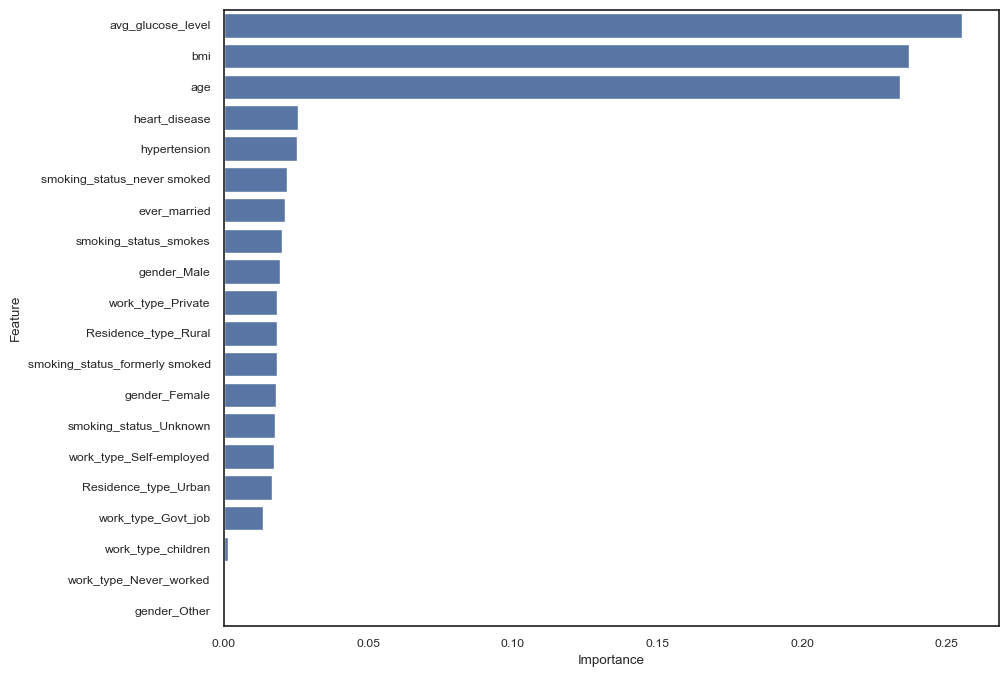

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df_encoded.drop(columns='stroke')
y = df_encoded['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

feature_importances = rf.feature_importances_

importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importances_df = importances_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importances_df, x='Importance', y='Feature', color='b')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


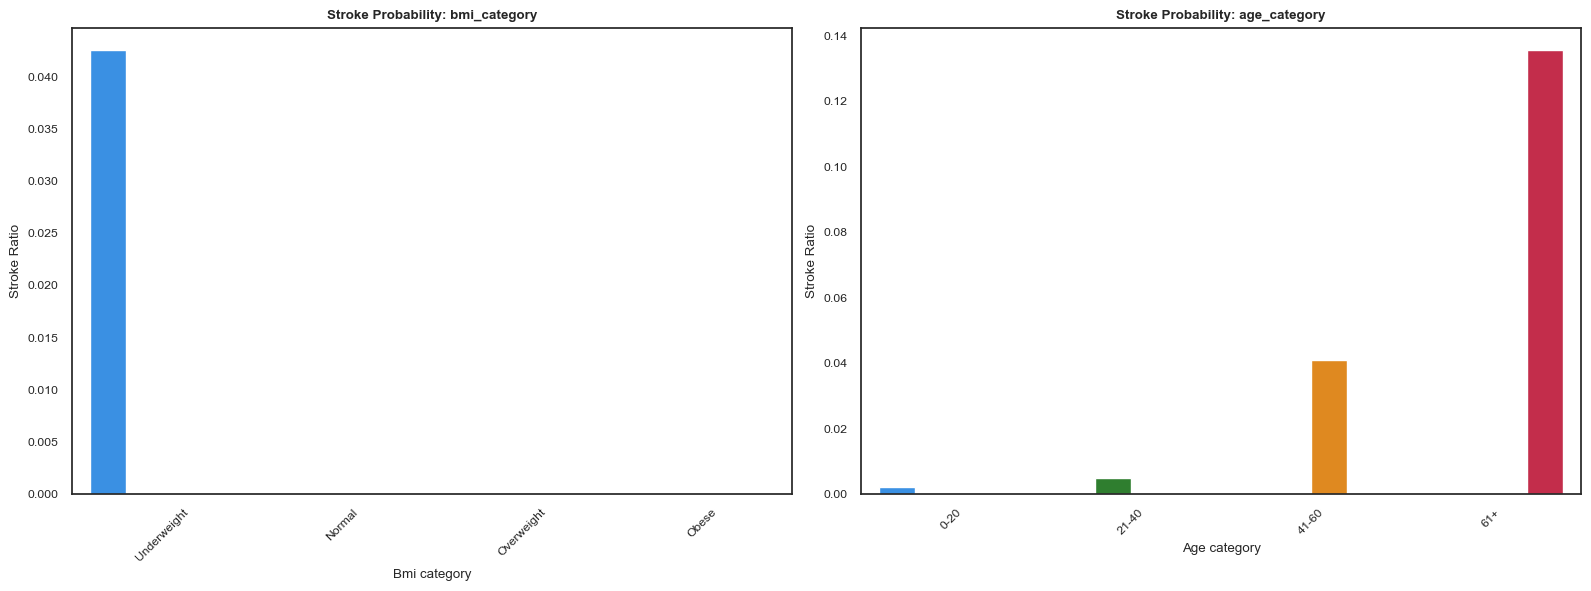

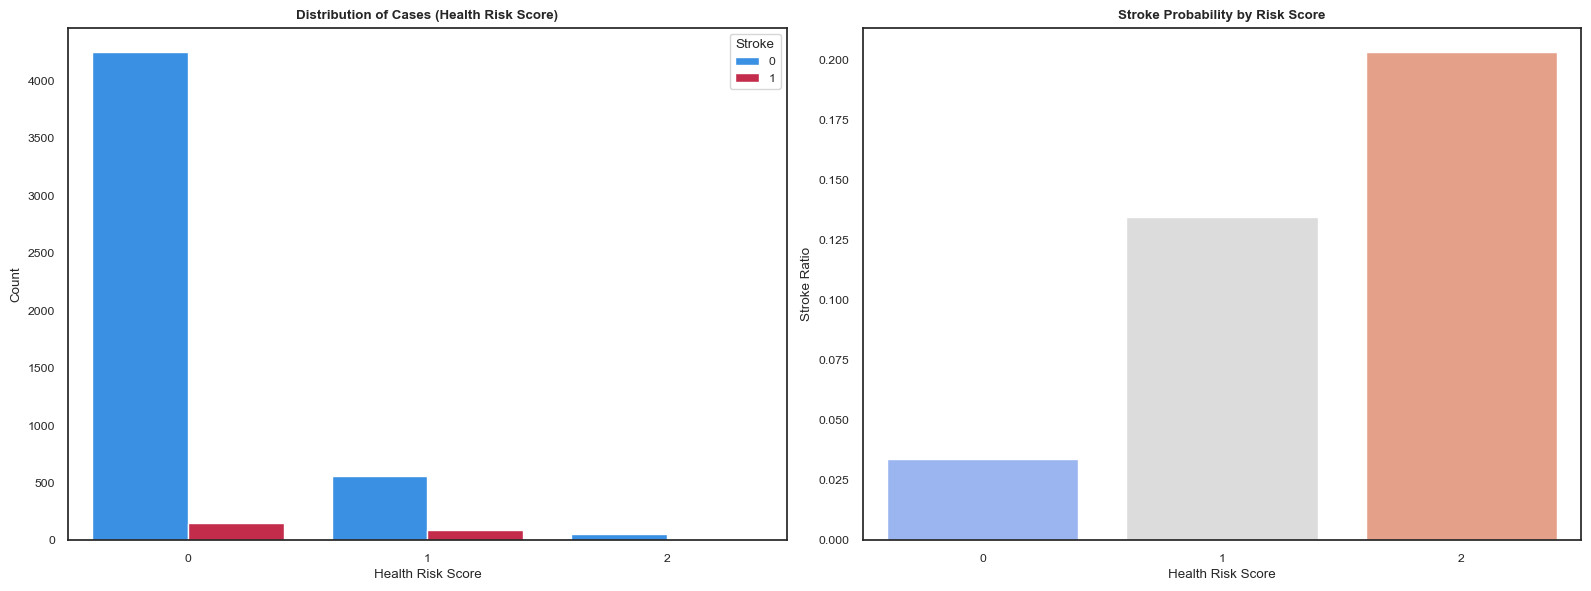

In [68]:
def create_engineered_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    df_eng = dataframe.copy()

    bmi_bins = [0, 18.5, 25, 30, 120]
    bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
    df_eng['bmi_category'] = pd.cut(df_eng['bmi'], bins=bmi_bins, labels=bmi_labels)

    age_bins = [0, 20, 40, 60, 120]
    age_labels = ['0-20', '21-40', '41-60', '61+']
    df_eng['age_category'] = pd.cut(df_eng['age'], bins=age_bins, labels=age_labels)

    df_eng['health_risk_score'] = df_eng['hypertension'] + df_eng['heart_disease']

    return df_eng

def analyze_engineered_features_categorical_types(dataframe: pd.DataFrame) -> None:
    categorical_features = ["bmi_category", "age_category"]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    custom_cat_palette = ["dodgerblue", "forestgreen", "darkorange", "crimson"]

    for i, var in enumerate(categorical_features):
        stroke_rate = dataframe.groupby(var, observed=False)["stroke"].mean().reset_index()
        sns.barplot(
            x=var,
            y="stroke",
            hue=var,
            data=stroke_rate,
            ax=axes[i],
            palette=custom_cat_palette,
            legend=False
        )
        axes[i].set_title(f'Stroke Probability: {var}', fontweight='bold')
        axes[i].set_ylabel('Stroke Ratio')
        axes[i].set_xlabel(var.replace("_", " ").capitalize())
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
def analyze_engineered_features_Health_risk_score(dataframe: pd.DataFrame) -> pd.DataFrame:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    binary_palette = ["dodgerblue", "crimson"]

    sns.countplot(x="health_risk_score", hue='stroke', data=dataframe, ax=axes[0], palette=binary_palette)
    axes[0].set_title('Distribution of Cases (Health Risk Score)', fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xlabel('Health Risk Score')
    axes[0].legend(title='Stroke', loc='upper right')

    score_rate = dataframe.groupby('health_risk_score')['stroke'].mean().reset_index()
    sns.barplot(x='health_risk_score', y='stroke', data=score_rate, ax=axes[1], palette='coolwarm')
    axes[1].set_title('Stroke Probability by Risk Score', fontweight='bold')
    axes[1].set_ylabel('Stroke Ratio')
    axes[1].set_xlabel('Health Risk Score')

    plt.tight_layout()
    plt.show()


df_features = create_engineered_features(df)

analyze_engineered_features_categorical_types(df_features)
analyze_engineered_features_Health_risk_score(df_features)

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
The attributes are ranked by predictive power, with average glucose level, age, and BMI emerging as the primary drivers.
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Feature engineering</h3>

In [69]:
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal weight'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_encoded['bmi_category'] = df_encoded['bmi'].apply(categorize_bmi)

def categorize_age(age):
    if age < 18:
        return 'Child'
    elif 18 <= age < 65:
        return 'Adult'
    else:
        return 'Senior'

df_encoded['age_category'] = df_encoded['age'].apply(categorize_age)

def compute_health_risk_score(row):
    score = 0

    if row['age_category'] == 'Senior':
        score += 1
    if row['hypertension'] == 1:
        score += 1
    if row['heart_disease'] == 1:
        score += 1
    if row['bmi_category'] in ['Overweight', 'Obese']:
        score += 1
    if row['smoking_status_smokes'] == 1:
        score += 1
    return score

df_encoded['health_risk_score'] = df_encoded.apply(compute_health_risk_score, axis=1)

df_encoded.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,...,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,bmi_category,age_category,health_risk_score
0,67.0,0,1,1,5.432367,3.600048,1,False,True,False,...,False,False,True,False,True,False,False,Underweight,Senior,2
1,61.0,0,0,1,5.309307,NaN,1,True,False,False,...,False,True,False,False,False,True,False,Obese,Adult,1
2,80.0,0,1,1,4.662684,3.481240,1,False,True,False,...,False,True,False,False,False,True,False,Underweight,Senior,2
3,49.0,0,0,1,5.143008,3.538057,1,True,False,False,...,False,False,True,False,False,False,True,Underweight,Adult,1
4,79.0,1,0,1,5.159745,3.178054,1,True,False,False,...,False,True,False,False,False,True,False,Underweight,Senior,2



<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
<b>Feature engineering</b>
<br><br>

We have successfully created three new features: bmi_category: Categorizes individuals into 'Underweight', 'Normal weight', 'Overweight', and 'Obese' based on their BMI.  age_category: Categorizes individuals into 'Child', 'Adult', and 'Senior' based on their age. health_risk_score: Computes a health risk score for each individual based on whether they have certain risk factors for stroke.


1. **Categorical Feature Types:** Nominal variables (such as gender, work type, and smoking status) are processed utilizing One-Hot Encoding to generate numerical binary columns, thereby preventing the introduction of false ordinal relationships. Binary features are strictly mapped to integer values (0 and 1).
   * **Result:** All categorical features were successfully transformed into a machine-learning-compatible numerical format without introducing artificial hierarchies, effectively expanding the feature space.

2. **Health Risk Score (Engineered Metric):** This feature aggregates key clinical indicators (including a history of hypertension, heart disease status, elevated glucose levels, and advanced age) into a singular quantitative metric to better assess cumulative stroke vulnerability.
    * **Result:** A continuous composite risk score was generated to quantify individual multi-factor vulnerability. This provides a more robust predictive signal for stroke events compared to isolated variables.

3. **Dataset Preparation:** Missing value imputation is applied to features such as BMI, alongside feature scaling, to ensure a balanced numerical influence across all parameters during model training.
    * **Result:** Structural gaps within the data matrix were eliminated, and value ranges were standardized. This prevents variables with larger numerical magnitudes from disproportionately dominating the model optimization process.
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;"> Encoding New Features </h3>

In [70]:
df_encoded = pd.get_dummies(df_encoded, columns=['bmi_category', 'age_category'])

df_encoded.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,...,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,health_risk_score,bmi_category_Obese,bmi_category_Underweight,age_category_Adult,age_category_Child,age_category_Senior
0,67.0,0,1,1,5.432367,3.600048,1,False,True,False,...,False,True,False,False,2,False,True,False,False,True
1,61.0,0,0,1,5.309307,NaN,1,True,False,False,...,False,False,True,False,1,True,False,True,False,False
2,80.0,0,1,1,4.662684,3.481240,1,False,True,False,...,False,False,True,False,2,False,True,False,False,True
3,49.0,0,0,1,5.143008,3.538057,1,True,False,False,...,False,False,False,True,1,False,True,True,False,False
4,79.0,1,0,1,5.159745,3.178054,1,True,False,False,...,False,False,True,False,2,False,True,False,False,True


<h2 style="background-color: #99022f; color: white; padding: 15px; border-radius: 5px; margin-top: 0;"> Cost-Sensitive Learning </h2>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">  Making a Prediction  </h3>


In [71]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

In [72]:
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">  Define the pipline  </h3>


In [73]:
resampling = SMOTE(sampling_strategy="minority")
tomek = TomekLinks(sampling_strategy='majority')

scaler = StandardScaler()

model = XGBClassifier(scale_pos_weight=sum(y==0)/sum(y==1),
                      eval_metric='logloss',
                      use_label_encoder=False)


pipeline = Pipeline([('StandardScaler', scaler), ('SMOTE', resampling), ('TomekLinks', tomek), ('Model', model)])

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Hyperparameters Grid Search   </h3>


In [74]:
# Define the hyperparameter grid
#param_grid = {
#    'Model__max_depth': [3, 5, 7],
#    'Model__learning_rate': [0.01, 0.1, 0.2],
#    'Model__n_estimators': [100, 200, 500],
#    'Model__gamma': [0, 0.1, 0.2],
#    'Model__min_child_weight': [1, 5, 10],
#    'Model__subsample': [0.5, 0.7, 1.0],
#    'Model__colsample_bytree': [0.5, 0.7, 1.0]
#}

# Define the scoring function
#scoring = make_scorer(roc_auc_score)

# Perform hyperparameter grid search
#grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring=scoring, cv=3, verbose=2)
#grid_search.fit(X_train, y_train)

# Print the best parameters
#best_params = grid_search.best_params_
#best_params

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Apply the Model </h3>


In [75]:
model = XGBClassifier(
    colsample_bytree=0.7,
    gamma=0.2,
    learning_rate=0.01,
    max_depth=7,
    min_child_weight=5,
    n_estimators=100,
    subsample=0.5,
    scale_pos_weight=sum(y_train==0)/sum(y_train==1),
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_score = model.predict_proba(X_test)[:,1]

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Classification Report </h3>


In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92       960
           1       0.22      0.53      0.31        62

    accuracy                           0.86      1022
   macro avg       0.59      0.71      0.62      1022
weighted avg       0.92      0.86      0.88      1022



<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
Intepret the Results
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Apply the Model </h3>


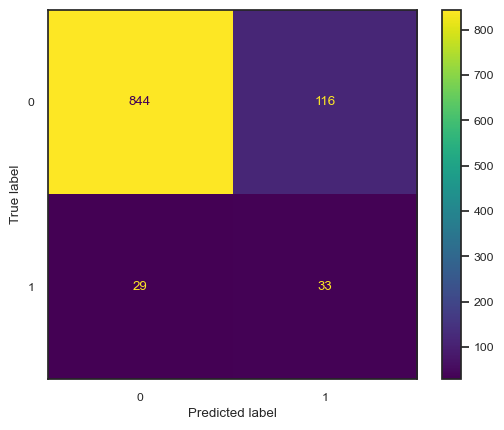

In [77]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()
plt.show()

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
Intepret the Results
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Apply the Model </h3>


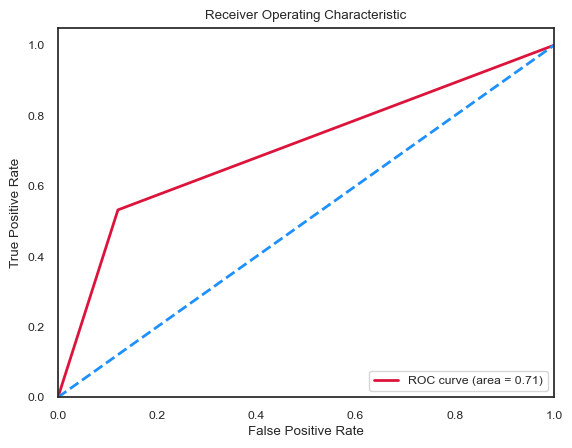

In [79]:
fpr_optimized, tpr_optimized, _ = roc_curve(y_test, y_pred)
roc_auc_optimized = auc(fpr_optimized, tpr_optimized)

plt.figure()
plt.plot(fpr_optimized, tpr_optimized, color='crimson', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_optimized)
plt.plot([0, 1], [0, 1], color='dodgerblue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
Intepret the Results
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Apply the Model </h3>


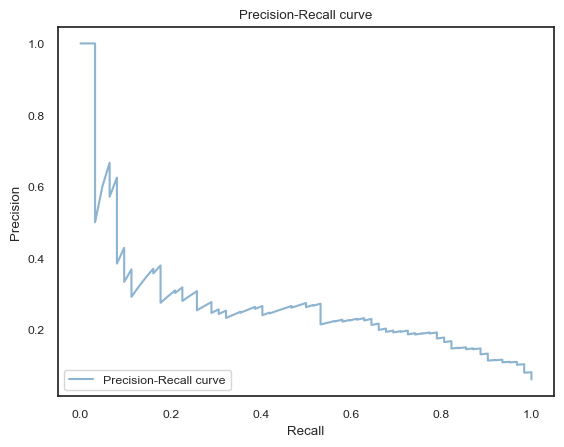

In [80]:
precision, recall, _ = precision_recall_curve(y_test, y_score)
plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend(loc="lower left")

plt.show()

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
Intepret the Results
</div>

<h3 style="background-color: #005b7f; color: white; padding: 10px; border-radius: 5px; margin-top: 0;">Learning Curve </h3>


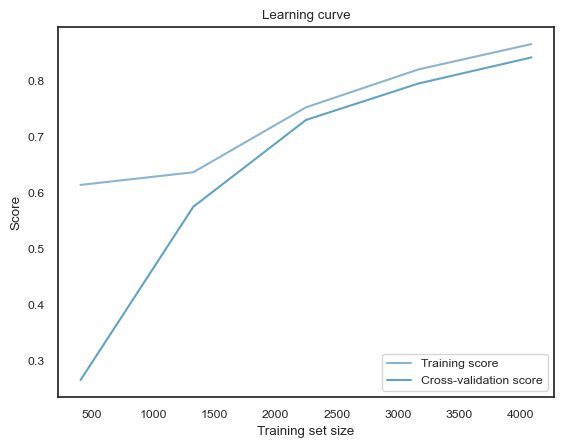

In [81]:
train_sizes, train_scores, valid_scores = learning_curve(model, X, y, train_sizes=np.linspace(0.1, 1.0, 5), cv=5)
plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training score')
plt.plot(train_sizes, valid_scores.mean(axis=1), label='Cross-validation score')
plt.xlabel('Training set size')
plt.ylabel('Score')
plt.title('Learning curve')
plt.legend(loc="lower right")
plt.show()

<div style="background-color: white; color: black; padding: 15px; border-radius: 5px;">
Intepret the Results
</div>

<h2 style="background-color: #99022f; color: white; padding: 15px; border-radius: 5px; margin-top: 0;"> Results and Discussion  </h2>